# 20 - Late Fusion Front-Only (7-Class)

Late Fusion menggabungkan prediksi CNN dan FCNN menggunakan weighted average.
Bobot optimal dicari dengan grid search pada test set.

**3 Skenario:** B1, B2, B3

In [1]:
import sys, os, json
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import DataLoader
from collections import Counter
from sklearn.metrics import f1_score, accuracy_score
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from training.models import EmotionCNN, EmotionFCNN
from training.utils import (
    EmotionImageDataset, EmotionLandmarkDataset, EmotionMultimodalDataset,
    get_class_weights, train_model, full_evaluation,
    plot_training_history, plot_confusion_matrix, plot_per_class_f1
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)})")

Device: cuda
GPU: Tesla T4)


In [2]:
DATASET_DIR = PROJECT_ROOT / "data" / "dataset_frontonly"
DATASET_AUG_DIR = PROJECT_ROOT / "data" / "dataset_frontonly_augmented"
OUTPUT_DIR = PROJECT_ROOT / "models" / "frontonly" / "7class"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH_SIZE = 32
EPOCHS = 50
LR = 0.0001
PATIENCE = 15
NUM_CLASSES = 7
EMOTIONS = ["neutral", "happy", "sad", "angry", "fearful", "disgusted", "surprised"]

print(f"Dataset: {DATASET_DIR}")
print(f"Output: {OUTPUT_DIR}")

Dataset: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset_frontonly
Output: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/7class


In [3]:
# Load multimodal test set
test_ds = EmotionMultimodalDataset(
    DATASET_DIR / "X_test_images.npy",
    DATASET_DIR / "X_test_landmarks.npy",
    DATASET_DIR / "y_test.npy")
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"Test: {len(test_ds)} samples")

CNN_DIR = PROJECT_ROOT / "models" / "frontonly/7class"
FCNN_DIR = PROJECT_ROOT / "models" / "frontonly/7class"

def late_fusion_eval(cnn_path, fcnn_path, title):
    cnn_model = EmotionCNN(num_classes=NUM_CLASSES).to(device)
    fcnn_model = EmotionFCNN(num_classes=NUM_CLASSES).to(device)
    cnn_model.load_state_dict(torch.load(cnn_path, map_location=device, weights_only=True))
    fcnn_model.load_state_dict(torch.load(fcnn_path, map_location=device, weights_only=True))
    cnn_model.eval(); fcnn_model.eval()

    cnn_probs_all, fcnn_probs_all, labels_all = [], [], []
    with torch.no_grad():
        for images, landmarks, labels in test_loader:
            cnn_probs_all.append(torch.softmax(cnn_model(images.to(device)), dim=1).cpu().numpy())
            fcnn_probs_all.append(torch.softmax(fcnn_model(landmarks.to(device)), dim=1).cpu().numpy())
            labels_all.append(labels.numpy())

    cnn_probs = np.concatenate(cnn_probs_all)
    fcnn_probs = np.concatenate(fcnn_probs_all)
    lbls = np.concatenate(labels_all)

    best_f1, best_w = 0, 0.5
    for w in np.arange(0.0, 1.05, 0.05):
        preds = (w * cnn_probs + (1-w) * fcnn_probs).argmax(axis=1)
        f1 = f1_score(lbls, preds, average="macro", zero_division=0)
        if f1 > best_f1:
            best_f1 = f1; best_w = w; best_preds = preds

    acc = accuracy_score(lbls, best_preds)
    wf1 = f1_score(lbls, best_preds, average="weighted", zero_division=0)
    print(f"\n{title}")
    print(f"  Best CNN weight: {best_w:.2f} | Acc: {acc:.4f} | Macro F1: {best_f1:.4f} | W-F1: {wf1:.4f}")
    return {"test_accuracy": acc, "test_macro_f1": best_f1, "test_weighted_f1": wf1, "best_cnn_weight": best_w, "labels": lbls.tolist(), "predictions": best_preds.tolist()}

Test: 1036 samples


## Evaluasi Late Fusion — B1, B2, B3

In [4]:
results_b1 = late_fusion_eval(
    CNN_DIR / "cnn_b1.pth", FCNN_DIR / "fcnn_b1.pth",
    "Late Fusion B1 - Baseline (Front-Only)")

results_b2 = late_fusion_eval(
    CNN_DIR / "cnn_b2.pth", FCNN_DIR / "fcnn_b2.pth",
    "Late Fusion B2 - Class Weights (Front-Only)")

results_b3 = late_fusion_eval(
    CNN_DIR / "cnn_b3.pth", FCNN_DIR / "fcnn_b3.pth",
    "Late Fusion B3 - Augmented (Front-Only)")


Late Fusion B1 - Baseline (Front-Only)
  Best CNN weight: 0.25 | Acc: 0.9305 | Macro F1: 0.1707 | W-F1: 0.9172



Late Fusion B2 - Class Weights (Front-Only)
  Best CNN weight: 0.50 | Acc: 0.9411 | Macro F1: 0.1513 | W-F1: 0.9213



Late Fusion B3 - Augmented (Front-Only)
  Best CNN weight: 0.25 | Acc: 0.9334 | Macro F1: 0.1747 | W-F1: 0.9192


## Ringkasan

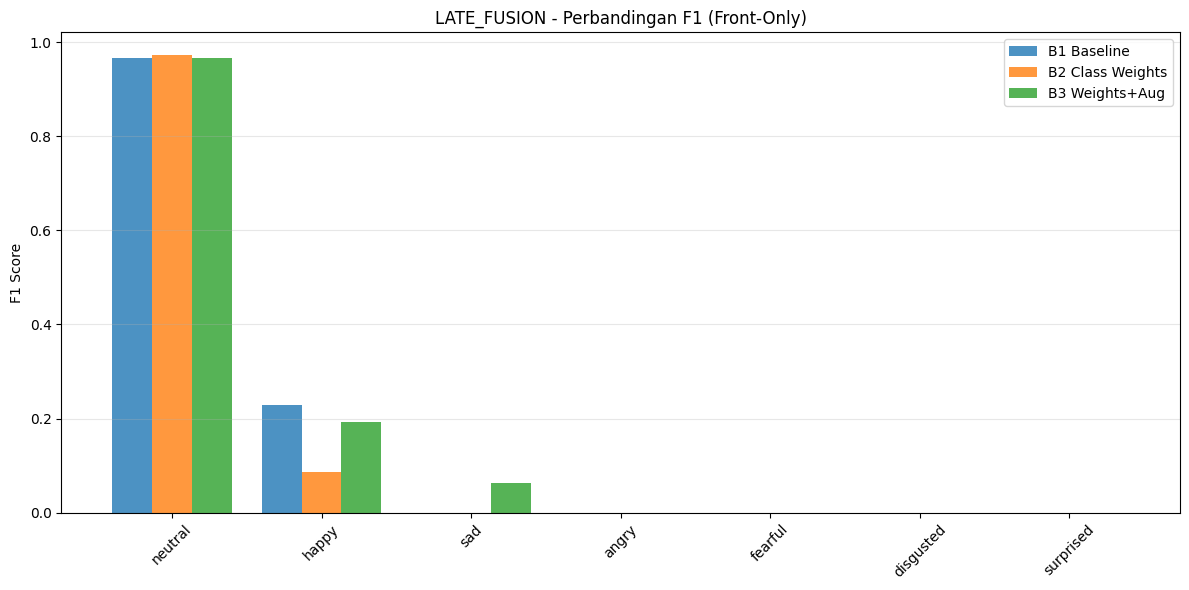

RINGKASAN LATE_FUSION FRONT-ONLY
Skenario                    Accuracy   Macro F1  Weighted F1
----------------------------------------------------------------------
B1 Baseline                   0.9305     0.1707       0.9172
B2 Class Weights              0.9411     0.1513       0.9213
B3 Weights+Aug                0.9334     0.1747       0.9192

Saved to /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/7class/late_fusion_results.json


In [5]:
# Perbandingan
all_results = {
    "B1 Baseline": results_b1,
    "B2 Class Weights": results_b2,
    "B3 Weights+Aug": results_b3,
}
plot_per_class_f1(all_results, "LATE_FUSION - Perbandingan F1 (Front-Only)")

print("=" * 70)
print("RINGKASAN LATE_FUSION FRONT-ONLY")
print("=" * 70)
print(f"{'Skenario':<25} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("-" * 70)
for name, r in all_results.items():
    print(f"{name:<25} {r['test_accuracy']:>10.4f} {r['test_macro_f1']:>10.4f} {r['test_weighted_f1']:>12.4f}")

results_save = {}
for name, r in all_results.items():
    results_save[name] = {
        "accuracy": float(r["test_accuracy"]),
        "macro_f1": float(r["test_macro_f1"]),
        "weighted_f1": float(r["test_weighted_f1"]),
    }
with open(OUTPUT_DIR / "late_fusion_results.json", "w") as f:
    json.dump(results_save, f, indent=2)
print(f"\nSaved to {OUTPUT_DIR / 'late_fusion_results.json'}")